In [86]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

print("imported")

imported


In [87]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jboysen/global-food-prices/wfp_market_food_prices.csv


In [88]:
df=pd.read_csv(
    "/kaggle/input/datasets/jboysen/global-food-prices/wfp_market_food_prices.csv",
    encoding="latin1"
)
print(df.head())

   adm0_id    adm0_name  adm1_id   adm1_name  mkt_id  mkt_name  cm_id cm_name  \
0        1  Afghanistan      272  Badakhshan     266  Fayzabad     55   Bread   
1        1  Afghanistan      272  Badakhshan     266  Fayzabad     55   Bread   
2        1  Afghanistan      272  Badakhshan     266  Fayzabad     55   Bread   
3        1  Afghanistan      272  Badakhshan     266  Fayzabad     55   Bread   
4        1  Afghanistan      272  Badakhshan     266  Fayzabad     55   Bread   

   cur_id cur_name  pt_id pt_name  um_id um_name  mp_month  mp_year  mp_price  \
0      87      AFN     15  Retail      5      KG         1     2014      50.0   
1      87      AFN     15  Retail      5      KG         2     2014      50.0   
2      87      AFN     15  Retail      5      KG         3     2014      50.0   
3      87      AFN     15  Retail      5      KG         4     2014      50.0   
4      87      AFN     15  Retail      5      KG         5     2014      50.0   

  mp_commoditysource  
0  

In [89]:
#to extract dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 743914 entries, 0 to 743913
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   adm0_id             743914 non-null  int64  
 1   adm0_name           743914 non-null  object 
 2   adm1_id             743914 non-null  int64  
 3   adm1_name           729965 non-null  object 
 4   mkt_id              743914 non-null  int64  
 5   mkt_name            743914 non-null  object 
 6   cm_id               743914 non-null  int64  
 7   cm_name             743914 non-null  object 
 8   cur_id              743914 non-null  int64  
 9   cur_name            743914 non-null  object 
 10  pt_id               743914 non-null  int64  
 11  pt_name             743914 non-null  object 
 12  um_id               743914 non-null  int64  
 13  um_name             743914 non-null  object 
 14  mp_month            743914 non-null  int64  
 15  mp_year             743914 non-nul

In [90]:
df.describe()

,adm0_id,adm1_id,mkt_id,cm_id,cur_id,pt_id,um_id,mp_month,mp_year,mp_price
count,743914.000000,743914.000000,743914.000000,743914.000000,743914.000000,743914.000000,743914.000000,743914.000000,743914.000000,7.439140e+05
mean,929.754832,17779.426232,885.962341,161.130914,57.325319,14.930508,10.562171,6.379772,2012.516549,4.196333e+03
std,6595.353806,81345.242217,540.492854,117.826297,23.140366,0.277872,13.160485,3.434972,3.669519,5.549296e+04
min,1.000000,0.000000,80.000000,50.000000,22.000000,14.000000,5.000000,1.000000,1992.000000,0.000000e+00
25%,115.000000,1510.000000,377.000000,67.000000,30.000000,15.000000,5.000000,3.000000,2011.000000,3.000000e+01
50%,170.000000,2207.000000,912.000000,110.000000,63.000000,15.000000,5.000000,6.000000,2013.000000,1.750000e+02
75%,205.000000,21969.000000,1134.000000,233.000000,77.000000,15.000000,5.000000,9.000000,2015.000000,5.000000e+02
max,70001.000000,900022.000000,2094.000000,490.000000,95.000000,18.000000,100.000000,12.000000,2017.000000,5.833333e+06


In [91]:
# to check null values
print(df.isnull().sum())
#to check duplicated prices in dataset
print(df.duplicated().sum())
#commodities we have
print(df["cm_name"].nunique())

adm0_id                   0
adm0_name                 0
adm1_id                   0
adm1_name             13949
mkt_id                    0
mkt_name                  0
cm_id                     0
cm_name                   0
cur_id                    0
cur_name                  0
pt_id                     0
pt_name                   0
um_id                     0
um_name                   0
mp_month                  0
mp_year                   0
mp_price                  0
mp_commoditysource        0
dtype: int64
0
321


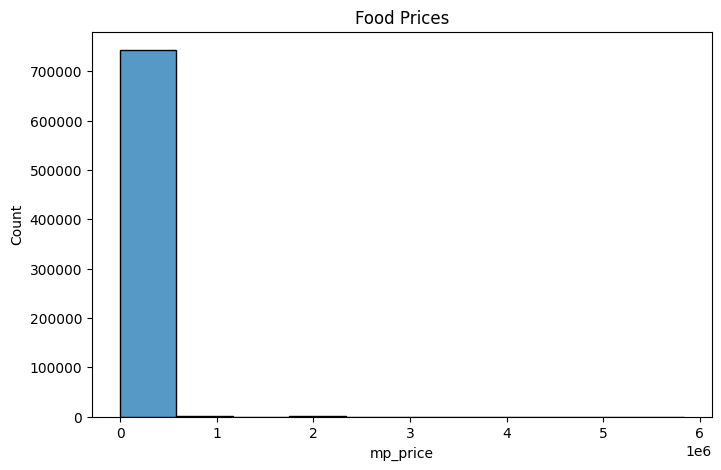

In [92]:
#now visualize the data
plt.figure(figsize=(8,5))
sns.histplot(df['mp_price'],bins=10)
plt.title("Food Prices")
plt.show()

In [93]:
"""
above graph shows very weird behavior, which means each country has its own price for each commodity
means dataset does no have one curreny or one scale of price for all commodities
"""

'\nabove graph shows very weird behavior, which means each country has its own price for each commodity\nmeans dataset does no have one curreny or one scale of price for all commodities\n'

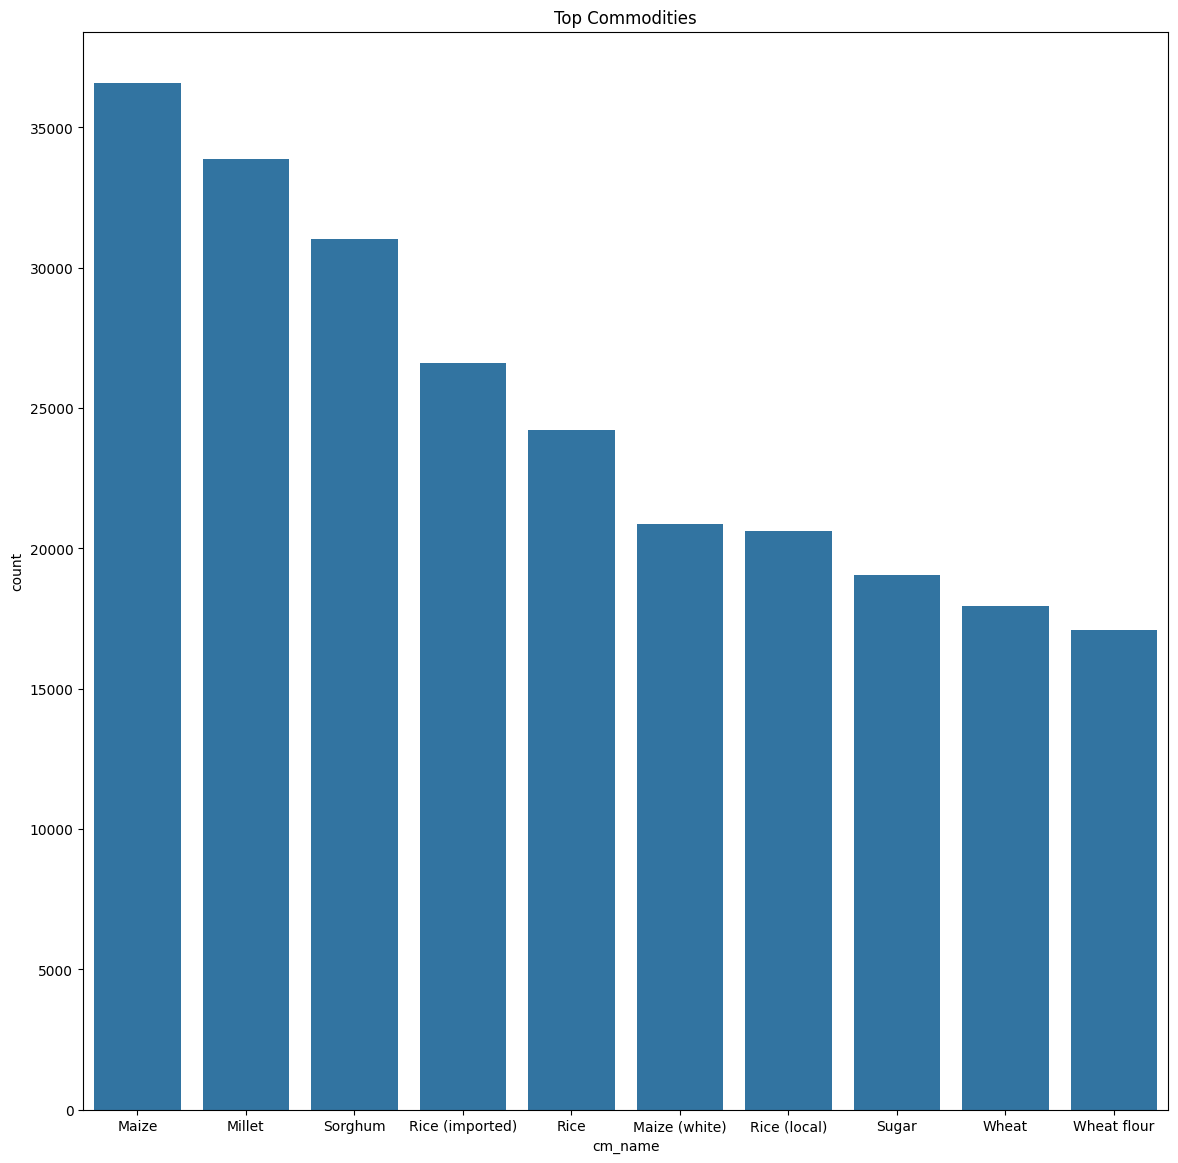

In [94]:
plt.figure(figsize=(14,14))
sns.countplot(x=df["cm_name"],order=df["cm_name"].value_counts().index[:10])
plt.title("Top Commodities")
plt.show()

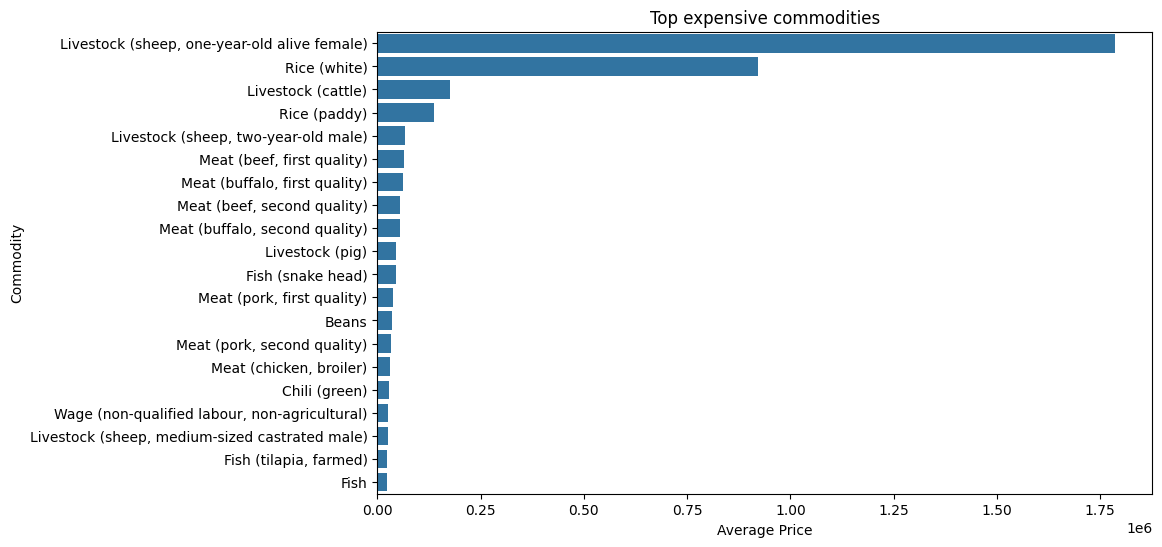

In [95]:
#to visualize top expensive commodities
top = df.groupby('cm_name')['mp_price'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x=top.values, y=top.index)

plt.title("Top expensive commodities")
plt.xlabel("Average Price")
plt.ylabel("Commodity")

plt.show()

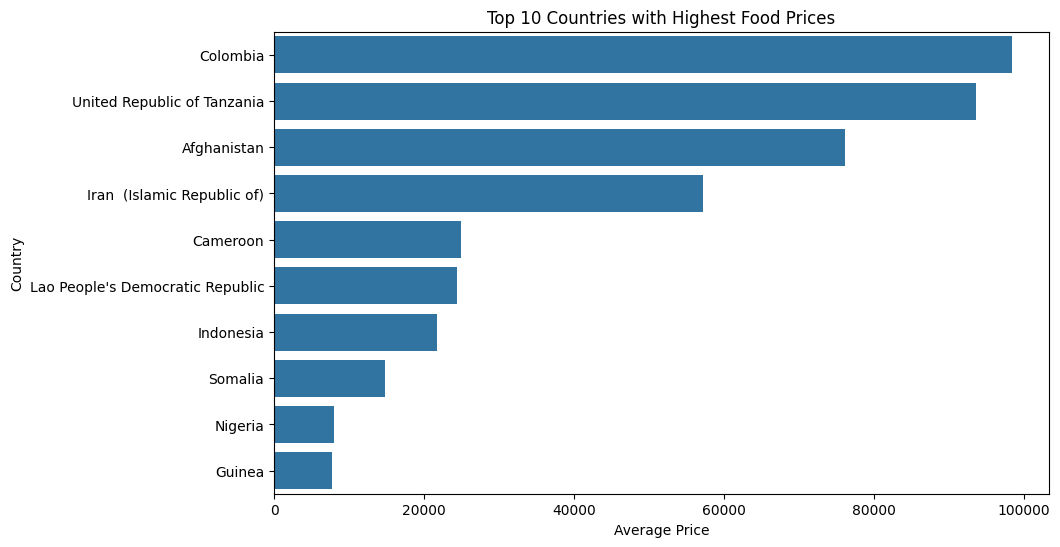

In [96]:
#countries with high prices
country_price = df.groupby('adm0_name')['mp_price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=country_price.values, y=country_price.index)

plt.title("Top 10 Countries with Highest Food Prices")
plt.xlabel("Average Price")
plt.ylabel("Country")

plt.show()

In [97]:
print(df['cur_name'].unique())
print(df['cur_name'].nunique())

['AFN' 'DZD' 'AMD' 'AZN' 'BDT' 'XOF' 'BTN' 'BOB' 'BIF' 'KHR' 'XAF' 'CVE'
 'COP' 'USD' 'CDF' 'DJF' 'ETB' 'GMD' 'GEL' 'GHS' 'GTQ' 'GNF' 'HTG' 'INR'
 'IDR' 'IRR' 'IQD' 'JOD' 'KES' 'KGS' 'LAK' 'LBP' 'LSL' 'LRD' 'MGA' 'MWK'
 'MRO' 'MZN' 'MMK' 'NPR' 'NGN' 'PKR' 'PEN' 'PHP' 'RWF' 'SOS'
 'Somaliland Shilling' 'LKR' 'SZL' 'SYP' 'TJS' 'TRY' 'UGX' 'UAH' 'TZS'
 'YER' 'ZMW' 'NIS' 'SDG' 'EGP' 'SSP']
61


In [98]:
#dropping some values
df = df.drop(columns=[
    'adm0_id','adm1_id','mkt_id',
    'cm_id','cur_id','pt_id','um_id'
])

"""
The dataset contains several id columns like adm0_id, adm1_id, and mkt_id.
These columns represent numeric identifiers for categorical features that
already exist in the dataset.Since the name columns provide clearer information and the ids do not add
additional value for analysis, i removed these id columns.
"""

'\nThe dataset contains several id columns like adm0_id, adm1_id, and mkt_id.\nThese columns represent numeric identifiers for categorical features that\nalready exist in the dataset.Since the name columns provide clearer information and the ids do not add\nadditional value for analysis, i removed these id columns.\n'

In [99]:
print(df.head())
#print(df['mp_commoditysource'].unique())
#print(df['mp_commoditysource'].unique())

     adm0_name   adm1_name  mkt_name cm_name cur_name pt_name um_name  \
0  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
1  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
2  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
3  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
4  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   

   mp_month  mp_year  mp_price mp_commoditysource  
0         1     2014      50.0                WFP  
1         2     2014      50.0                WFP  
2         3     2014      50.0                WFP  
3         4     2014      50.0                WFP  
4         5     2014      50.0                WFP  


In [100]:
"""
also removing mp_commoditysource,
as it is not helpful for predicting prices, also too unique values like WFP,
"""
df = df.drop(columns=['mp_commoditysource'])

In [101]:
print(df.head())

     adm0_name   adm1_name  mkt_name cm_name cur_name pt_name um_name  \
0  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
1  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
2  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
3  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
4  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   

   mp_month  mp_year  mp_price  
0         1     2014      50.0  
1         2     2014      50.0  
2         3     2014      50.0  
3         4     2014      50.0  
4         5     2014      50.0  


In [102]:
#saving file for future phases
df.to_csv("processed_food_prices.csv", index=False)

In [103]:
"""
Phase 02
Featuren Engineering
"""

'\nPhase 02\nFeaturen Engineering\n'

In [104]:
df=pd.read_csv("processed_food_prices.csv")
print(df.shape)

(743914, 10)


In [105]:
df = df.sort_values(
    ['adm0_name', 'cm_name', 'mkt_name', 'mp_year', 'mp_month']
).reset_index(drop=True)

#this will help in lag features

print("sorted")
print(df[['adm0_name', 'cm_name', 'mkt_name', 'mp_year', 'mp_month']].head(100))

sorted
      adm0_name cm_name   mkt_name  mp_year  mp_month
0   Afghanistan   Bread   Fayzabad     2014         1
1   Afghanistan   Bread   Fayzabad     2014         2
2   Afghanistan   Bread   Fayzabad     2014         3
3   Afghanistan   Bread   Fayzabad     2014         4
4   Afghanistan   Bread   Fayzabad     2014         5
..          ...     ...        ...      ...       ...
95  Afghanistan   Bread  Jalalabad     2015         6
96  Afghanistan   Bread  Jalalabad     2015         7
97  Afghanistan   Bread  Jalalabad     2015         8
98  Afghanistan   Bread  Jalalabad     2015         9
99  Afghanistan   Bread  Jalalabad     2015        10

[100 rows x 5 columns]


In [106]:
#Creating new date feature
df['date'] = pd.to_datetime(df['mp_year'].astype(str) + '-' + df['mp_month'].astype(str))

"""
this feature gives overall date instead of finding month, year separately
"""

'\nthis feature gives overall date instead of finding month, year separately\n'

In [107]:
#grouping columns by country,commodity, market
group_cols=["adm0_name","cm_name","mkt_name"]

df['lag_1m']  = df.groupby(group_cols)['mp_price'].shift(1)
df['lag_3m']  = df.groupby(group_cols)['mp_price'].shift(3)
df['lag_6m']  = df.groupby(group_cols)['mp_price'].shift(6)
df['lag_12m'] = df.groupby(group_cols)['mp_price'].shift(12)

"""
Lag features introduce NaN values at the start of each
country commodity market group because no historical
data exists for those early months.

these features will help to see trends how much price 
was before
"""

'\nLag features introduce NaN values at the start of each\ncountry commodity market group because no historical\ndata exists for those early months.\n\nthese features will help to see trends how much price \nwas before\n'

In [108]:
print(df.head())

     adm0_name   adm1_name  mkt_name cm_name cur_name pt_name um_name  \
0  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
1  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
2  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
3  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
4  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   

   mp_month  mp_year  mp_price       date  lag_1m  lag_3m  lag_6m  lag_12m  
0         1     2014      50.0 2014-01-01     NaN     NaN     NaN      NaN  
1         2     2014      50.0 2014-02-01    50.0     NaN     NaN      NaN  
2         3     2014      50.0 2014-03-01    50.0     NaN     NaN      NaN  
3         4     2014      50.0 2014-04-01    50.0    50.0     NaN      NaN  
4         5     2014      50.0 2014-05-01    50.0    50.0     NaN      NaN  


In [109]:
df['rolling_mean_3m'] = df.groupby(group_cols)['mp_price'] \
    .transform(lambda x: x.rolling(3, min_periods=1).mean())

df['rolling_mean_6m'] = df.groupby(group_cols)['mp_price'] \
    .transform(lambda x: x.rolling(6, min_periods=1).mean())

df['rolling_std_3m'] = df.groupby(group_cols)['mp_price'] \
    .transform(lambda x: x.rolling(3, min_periods=1).std().fillna(0))

df['rolling_std_6m'] = df.groupby(group_cols)['mp_price'] \
    .transform(lambda x: x.rolling(6, min_periods=1).std().fillna(0))

"""
rolling mean tells the trendof recent prices and
standard deviation tells how much prices are jumping around
"""

'\nrolling mean tells the trendof recent prices and\nstandard deviation tells how much prices are jumping around\n'

In [110]:
# How many different commodities does this market track?
df['market_diversity'] = df.groupby('mkt_name')['cm_name'].transform('nunique')

# Is this market expensive or cheap compared to national average?
national_avg = df.groupby(['adm0_name', 'cm_name'])['mp_price'].transform('mean')
market_avg   = df.groupby(['mkt_name',  'cm_name'])['mp_price'].transform('mean')
df['market_vs_national_avg'] = market_avg / (national_avg + 1e-5)

# Also keep: is current price above or below this country+commodity average?
df['price_vs_country_avg'] = df['mp_price'] / (national_avg + 1e-5)

print("Market context features")
print(df[['adm0_name', 'mkt_name', 'cm_name','market_diversity', 'market_vs_national_avg']].head(10))


"""
this tells is this market richer or poorer than average?
How does this market's price compare to the national average?
A market in a remote village is usually more expensive due to transport costs.
If the model knows this market is usually 20% above national average,
it can predict better.
"""

Market context features
     adm0_name  mkt_name cm_name  market_diversity  market_vs_national_avg
0  Afghanistan  Fayzabad   Bread                 8                1.155596
1  Afghanistan  Fayzabad   Bread                 8                1.155596
2  Afghanistan  Fayzabad   Bread                 8                1.155596
3  Afghanistan  Fayzabad   Bread                 8                1.155596
4  Afghanistan  Fayzabad   Bread                 8                1.155596
5  Afghanistan  Fayzabad   Bread                 8                1.155596
6  Afghanistan  Fayzabad   Bread                 8                1.155596
7  Afghanistan  Fayzabad   Bread                 8                1.155596
8  Afghanistan  Fayzabad   Bread                 8                1.155596
9  Afghanistan  Fayzabad   Bread                 8                1.155596


"\nthis tells is this market richer or poorer than average?\nHow does this market's price compare to the national average?\nA market in a remote village is usually more expensive due to transport costs.\nIf the model knows this market is usually 20% above national average,\nit can predict better.\n"

In [111]:
country_commodity_mean = df.groupby(['adm0_name', 'cm_name'])['mp_price'].transform('mean')
df['price_vs_country_avg'] = df['mp_price'] / country_commodity_mean
print(df.head(20))

"""
this features gives idea how price related to country avergae
"""

      adm0_name   adm1_name  mkt_name cm_name cur_name pt_name um_name  \
0   Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
1   Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
2   Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
3   Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
4   Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
5   Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
6   Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
7   Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
8   Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
9   Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
10  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
11  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
12  Afghanistan  Badakhshan  Fayzabad 

'\nthis features gives idea how price related to country avergae\n'

In [112]:
#year over year price chnage
df['yoy_price_change'] = (df['mp_price'] - df['lag_12m']) / (df['lag_12m'] + 1e-5)
print(df.head(30))

"""
year over year price chnage helps to analyze how price change over years
"""

      adm0_name   adm1_name  mkt_name cm_name cur_name pt_name um_name  \
0   Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
1   Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
2   Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
3   Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
4   Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
5   Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
6   Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
7   Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
8   Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
9   Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
10  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
11  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
12  Afghanistan  Badakhshan  Fayzabad 

'\nyear over year price chnage helps to analyze how price change over years\n'

In [113]:
print(df.head())

     adm0_name   adm1_name  mkt_name cm_name cur_name pt_name um_name  \
0  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
1  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
2  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
3  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   
4  Afghanistan  Badakhshan  Fayzabad   Bread      AFN  Retail      KG   

   mp_month  mp_year  mp_price  ... lag_6m  lag_12m  rolling_mean_3m  \
0         1     2014      50.0  ...    NaN      NaN             50.0   
1         2     2014      50.0  ...    NaN      NaN             50.0   
2         3     2014      50.0  ...    NaN      NaN             50.0   
3         4     2014      50.0  ...    NaN      NaN             50.0   
4         5     2014      50.0  ...    NaN      NaN             50.0   

   rolling_mean_6m  rolling_std_3m  rolling_std_6m  market_diversity  \
0             50.0             0.0             0.0      

In [119]:
from sklearn.preprocessing import LabelEncoder
"""
Machine learning models only understand numbers. They cannot read text
"""

text_columns = ['adm0_name', 'cm_name', 'mkt_name', 'pt_name', 'um_name', 'cur_name']

for col in text_columns:
    if col in df.columns:
        le = LabelEncoder()
        df[col + '_enc'] = le.fit_transform(df[col].astype(str))
        #print(f"Encoded {col} → {col}_enc")
        
print(df[['adm0_name', 'adm0_name_enc', 'cm_name', 'cm_name_enc']].head(1000))

       adm0_name  adm0_name_enc        cm_name  cm_name_enc
0    Afghanistan              0          Bread           30
1    Afghanistan              0          Bread           30
2    Afghanistan              0          Bread           30
3    Afghanistan              0          Bread           30
4    Afghanistan              0          Bread           30
..           ...            ...            ...          ...
995  Afghanistan              0  Fuel (diesel)          106
996  Afghanistan              0  Fuel (diesel)          106
997  Afghanistan              0  Fuel (diesel)          106
998  Afghanistan              0  Fuel (diesel)          106
999  Afghanistan              0  Fuel (diesel)          106

[1000 rows x 4 columns]


In [123]:
#K-means
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

km_cols = ['rolling_mean_3m', 'rolling_std_3m', 'yoy_price_change']

km_data = df[km_cols].fillna(0)

# Scale before K-Means so no single feature dominates
scaler_km = StandardScaler()
km_scaled = scaler_km.fit_transform(km_data)

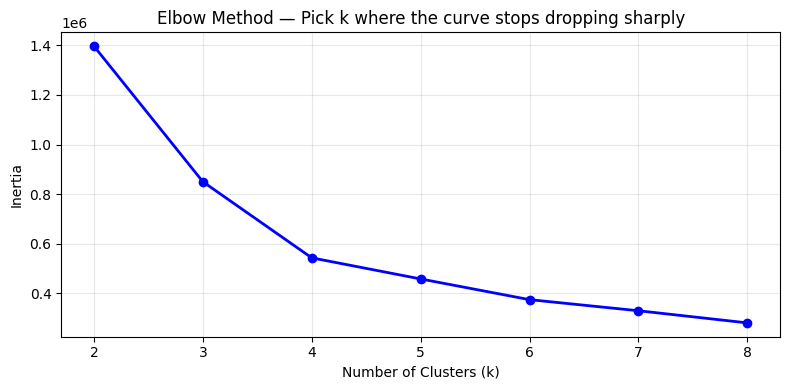

In [124]:
# Elbow method — find the right number of clusters
inertia = []
for k in range(2, 9):
    km_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_test.fit(km_scaled)
    inertia.append(km_test.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 9), inertia, 'bo-', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Pick k where the curve stops dropping sharply')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [125]:
"""
selecting k=4 from analyzing graph
"""
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['price_behavior_cluster'] = km_final.fit_predict(km_scaled)

# See what each cluster looks like
profile = df.groupby('price_behavior_cluster')[km_cols].mean().round(2)
print("Cluster profiles:")
print(profile)

Cluster profiles:
                        rolling_mean_3m  rolling_std_3m  yoy_price_change
price_behavior_cluster                                                   
0                               2819.14          171.78              0.16
1                            1693384.10        86728.51              0.15
2                            2302884.14       663824.55              0.46
3                              38921.36        12203.87            369.30


In [126]:
# Give each cluster a meaningful label based on its profile
med_mean = profile['rolling_mean_3m'].median()
med_std  = profile['rolling_std_3m'].median()

label_map = {}
for cid in profile.index:
    high_price = profile.loc[cid, 'rolling_mean_3m'] > med_mean
    high_vol   = profile.loc[cid, 'rolling_std_3m']  > med_std

    if   high_price and high_vol:     label_map[cid] = 3  # Expensive & volatile
    elif high_price and not high_vol: label_map[cid] = 2  # Expensive & stable
    elif not high_price and high_vol: label_map[cid] = 1  # Cheap & volatile
    else:                             label_map[cid] = 0  # Cheap & stable

df['price_behavior_cluster'] = df['price_behavior_cluster'].map(label_map)

print("\nCluster meaning:")
print("0 = Cheap & Stable")
print("1 = Cheap but Volatile")
print("2 = Expensive & Stable")
print("3 = Expensive & Volatile (Crisis Risk)")
print("\nDistribution:")
print(df['price_behavior_cluster'].value_counts().sort_index())


Cluster meaning:
0 = Cheap & Stable
1 = Cheap but Volatile
2 = Expensive & Stable
3 = Expensive & Volatile (Crisis Risk)

Distribution:
price_behavior_cluster
0    743338
3       576
Name: count, dtype: int64


In [129]:
print(df.columns)

Index(['adm0_name', 'adm1_name', 'mkt_name', 'cm_name', 'cur_name', 'pt_name',
       'um_name', 'mp_month', 'mp_year', 'mp_price', 'date', 'lag_1m',
       'lag_3m', 'lag_6m', 'lag_12m', 'rolling_mean_3m', 'rolling_mean_6m',
       'rolling_std_3m', 'rolling_std_6m', 'market_diversity',
       'market_vs_national_avg', 'price_vs_country_avg', 'yoy_price_change',
       'adm0_name_enc', 'cm_name_enc', 'mkt_name_enc', 'pt_name_enc',
       'um_name_enc', 'cur_name_enc', 'price_behavior_cluster'],
      dtype='object')


In [131]:
#Checking Features Importance
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error
import shap


"""
lag_1m, lag_3m, lag_6m, lag_12m => temporal memory
rolling_mean => trend
rolling_std => volatility
yoy_price_change => growth pattern
"""

FEATURE_COLS = [
    'cm_name_enc', 'mkt_name_enc', 'pt_name_enc', 'um_name_enc',
    'mp_month', 'mp_year',
    'lag_1m', 'lag_3m', 'lag_6m', 'lag_12m',
    'rolling_mean_3m', 'rolling_mean_6m',
    'rolling_std_3m',  'rolling_std_6m',
    'yoy_price_change', 'price_vs_country_avg',
    'market_diversity', 'market_vs_national_avg',
    'price_behavior_cluster'
]

donr


In [145]:
COUNTRY = "Pakistan"   #  change this to any country you want

df_country = df[df['adm0_name'] == COUNTRY].copy().reset_index(drop=True)
currency   = df_country['cur_name'].iloc[0]

print(f"Country  : {COUNTRY}")
print(f"Currency : {currency}")
print(f"Rows     : {len(df_country):,}")

Country  : Pakistan
Currency : PKR
Rows     : 4,307


In [153]:
# Keep only rows where lag_1m exists (drop first month of each group)
df_country = df_country.dropna(subset=['lag_1m']).reset_index(drop=True)

# Select features and target
feats = [c for c in FEATURE_COLS if c in df_country.columns]
X = df_country[feats].fillna(0)
y = df_country['mp_price']

# Time-based split: train on old data, test on recent data
# This is more honest than random split for time series
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Training rows : {len(X_train):,}")
print(f"Testing rows  : {len(X_test):,}")

Training rows : 3,377
Testing rows  : 845


Random Forest R²: 0.9193


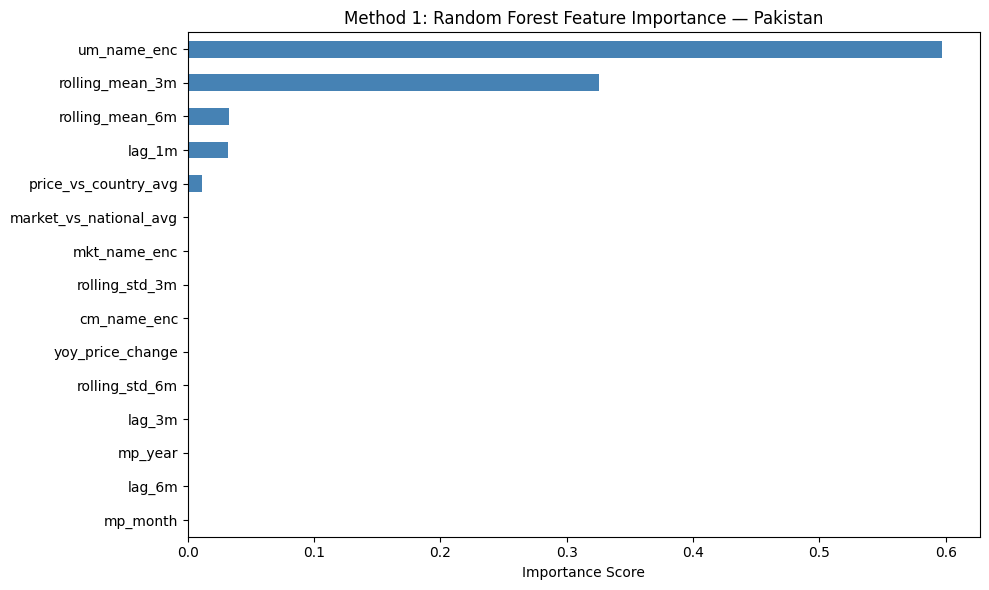

Top 5 features by Random Forest:
um_name_enc             0.597253
rolling_mean_3m         0.325424
rolling_mean_6m         0.032296
lag_1m                  0.032133
price_vs_country_avg    0.010899
dtype: float64


In [155]:
#using random forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f"Random Forest R²: {r2_score(y_test, rf.predict(X_test)):.4f}")

imp_rf = pd.Series(
    rf.feature_importances_,
    index=feats
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
imp_rf.head(15).plot(kind='barh', color='steelblue')
plt.title(f"Random Forest Feature Importance — {COUNTRY}")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 features by Random Forest:")
print(imp_rf.head(5))

XGBoost R²: 0.9528


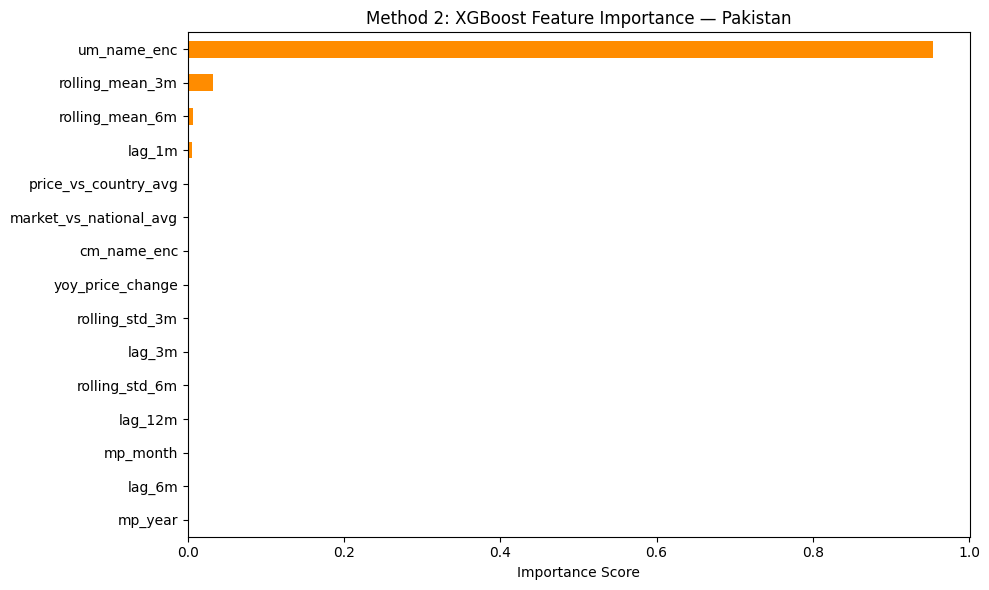

Top 5 features by XGBoost:
um_name_enc             0.953561
rolling_mean_3m         0.032536
rolling_mean_6m         0.006789
lag_1m                  0.005954
price_vs_country_avg    0.000716
dtype: float32


In [156]:
#using xgboost
xgb = XGBRegressor(random_state=42, verbosity=0, n_jobs=-1)
xgb.fit(X_train, y_train)
print(f"XGBoost R²: {r2_score(y_test, xgb.predict(X_test)):.4f}")


imp_xgb = pd.Series(
    xgb.feature_importances_,
    index=feats
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
imp_xgb.head(15).plot(kind='barh', color='darkorange')
plt.title(f"XGBoost Feature Importance — {COUNTRY}")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 features by XGBoost:")
print(imp_xgb.head(5))

LightGBM R²: 0.9627


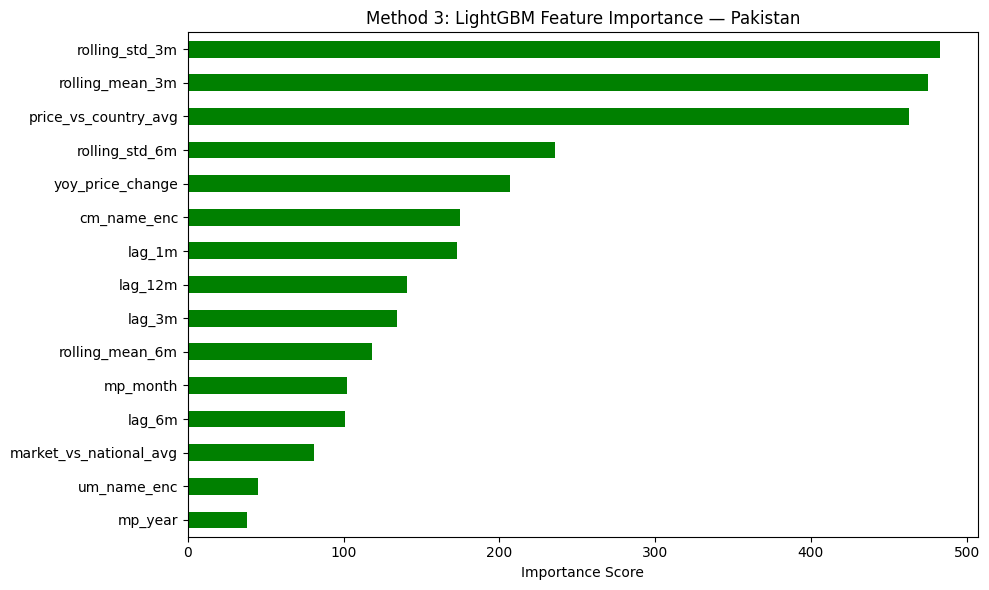

Top 5 features by LightGBM:
rolling_std_3m          483
rolling_mean_3m         475
price_vs_country_avg    463
rolling_std_6m          236
yoy_price_change        207
dtype: int32


In [157]:
#using lightbgm 
lgbm = lgb.LGBMRegressor(random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
print(f"LightGBM R²: {r2_score(y_test, lgbm.predict(X_test)):.4f}")

imp_lgbm = pd.Series(
    lgbm.feature_importances_,
    index=feats
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
imp_lgbm.head(15).plot(kind='barh', color='green')
plt.title(f"LightGBM Feature Importance — {COUNTRY}")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 features by LightGBM:")
print(imp_lgbm.head(5))

Computing SHAP values (runs on LightGBM model)...


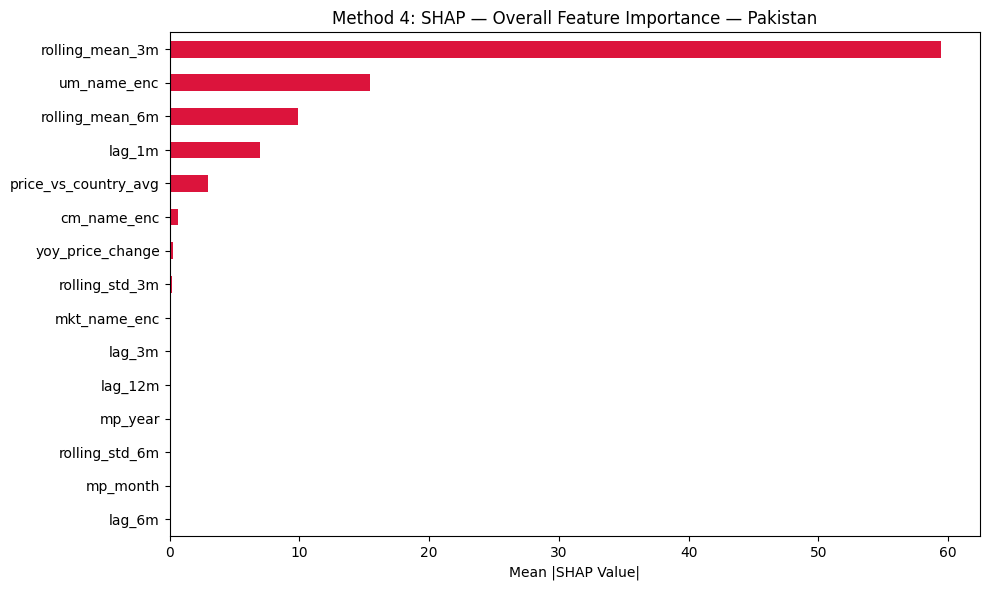

In [158]:
#using SHAP
print("Computing SHAP values (runs on LightGBM model)...")

# Take a sample of test data for speed
X_shap    = X_test.sample(min(500, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(lgbm)
shap_vals = explainer.shap_values(X_shap)

# Plot 1: Which features matter most overall?
imp_shap = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=feats
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
imp_shap.head(15).plot(kind='barh', color='crimson')
plt.title(f"SHAP — Overall Feature Importance — {COUNTRY}")
plt.xlabel("Mean |SHAP Value|")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

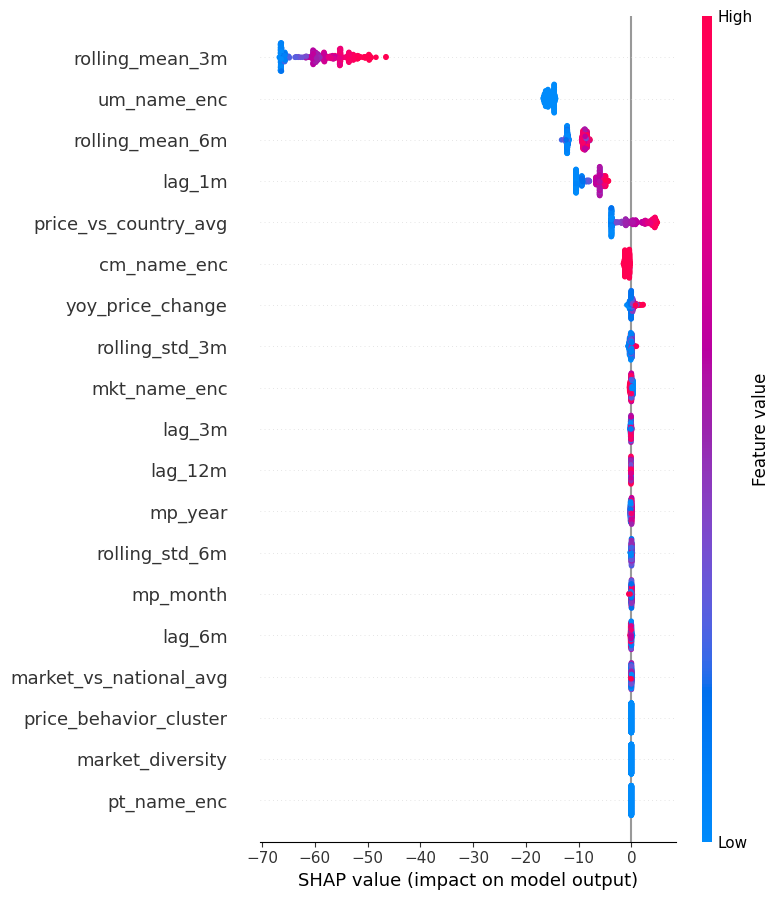

In [159]:
shap.summary_plot(shap_vals, X_shap, show=True)

# Red dot = high value of this feature pushes price UP
# Blue dot = high value of this feature pushes price DOWN

In [160]:
"""
SHAP explains the whole model. LIME explains one prediction at a time
by creating a simple local model around that single point
"""

#using Lime
import lime
import lime.lime_tabular

print("Setting up LIME explainer...")

# LIME needs to know the training data statistics
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train.values,
    feature_names  = feats,
    mode           = 'regression',
    random_state   = 42
)

Setting up LIME explainer...


Actual price    : 32.00 PKR
Predicted price : 32.34 PKR


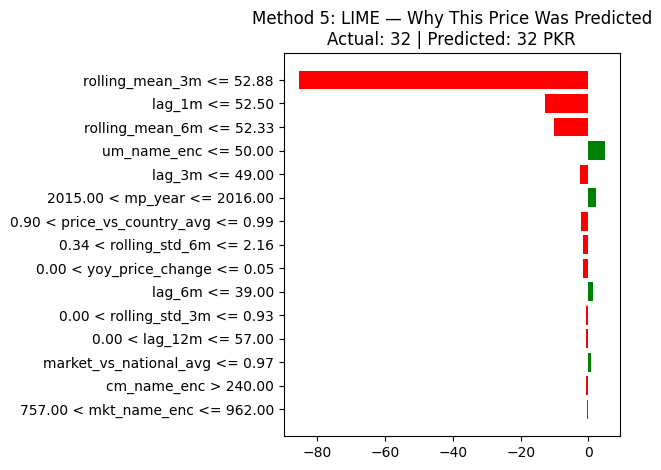

In [161]:
# Explain one prediction
# picking the first row from the test set
row_to_explain = X_test.iloc[0].values
actual_price   = y_test.iloc[0]
predicted_price = lgbm.predict(X_test.iloc[[0]])[0]

print(f"Actual price    : {actual_price:.2f} {currency}")
print(f"Predicted price : {predicted_price:.2f} {currency}")

# Generate LIME explanation
lime_exp = lime_explainer.explain_instance(
    data_row       = row_to_explain,
    predict_fn     = lgbm.predict,
    num_features   = 15    # show top 15 features
)

# Plot the explanation
lime_exp.as_pyplot_figure()
plt.title(f"LIME — Why This Price Was Predicted\n"
          f"Actual: {actual_price:.0f} | Predicted: {predicted_price:.0f} {currency}")
plt.tight_layout()
plt.show()


LIME importance across 5 different predictions:


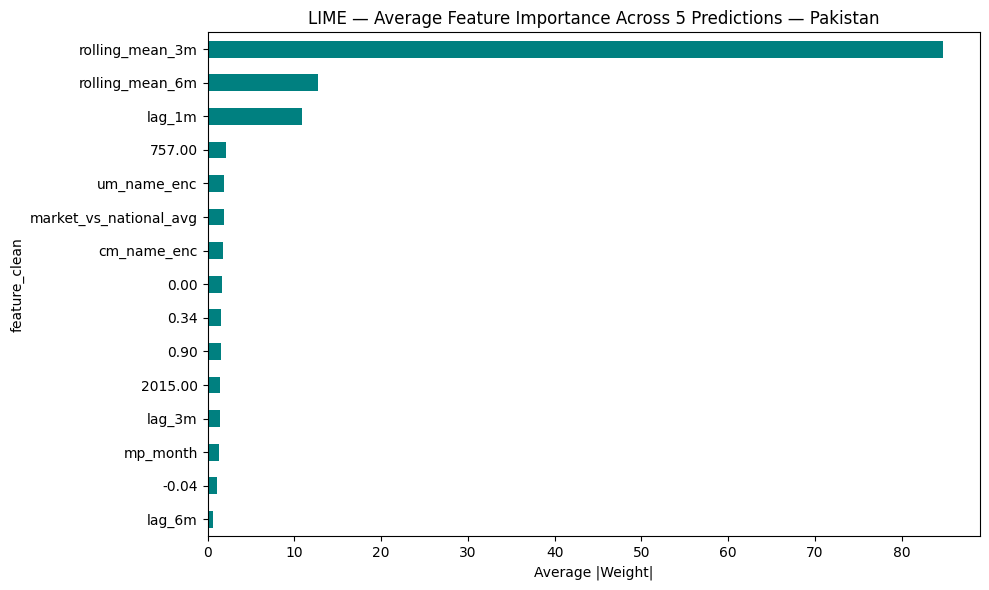

In [163]:
# Explain 5 different predictions and collect which features appear most
print("\nLIME importance across 5 different predictions:")

all_lime_weights = []

for i in range(5):
    row   = X_test.iloc[i].values
    exp   = lime_explainer.explain_instance(row, lgbm.predict, num_features=15)
    
    for feat_name, weight in exp.as_list():
        all_lime_weights.append({
            'feature' : feat_name,
            'weight'  : abs(weight),
            'row'     : i
        })

lime_df = pd.DataFrame(all_lime_weights)

# Clean feature names (LIME adds conditions like "lag_1m > 50.0")
# Extract just the feature name
lime_df['feature_clean'] = lime_df['feature'].apply(
    lambda x: x.split('>')[0].split('<')[0].split('=')[0].strip()
)

# Average absolute weight per feature
lime_summary = lime_df.groupby('feature_clean')['weight'] \
                       .mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
lime_summary.plot(kind='barh', color='teal')
plt.title(f"LIME — Average Feature Importance Across 5 Predictions — {COUNTRY}")
plt.xlabel("Average |Weight|")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [166]:
#comapring all algorithm to check important features
"""
Lime is shown separately above as individual prediction explanations.
Lime explains WHY a specific price was predicted, not global feature ranking.
"""

# Normalize each to 0-1 so they can be compared fairly
def normalize(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

# Build comparison table
# Note: LIME names may not match exactly due to condition strings
# So we use only the 4 clean methods for the table
comparison = pd.DataFrame({
    'RandomForest' : normalize(imp_rf),
    'XGBoost'      : normalize(imp_xgb),
    'LightGBM'     : normalize(imp_lgbm),
    'SHAP'         : normalize(imp_shap),
}).fillna(0)

comparison['Average'] = comparison.mean(axis=1)
comparison = comparison.sort_values('Average', ascending=False)

print(f"Top 10 Features — {COUNTRY} (across 4 quantitative methods):")
print(comparison.head(10).round(3))

Top 10 Features — Pakistan (across 4 quantitative methods):
                      RandomForest  XGBoost  LightGBM   SHAP  Average
rolling_mean_3m              0.545    0.034     0.983  1.000    0.641
um_name_enc                  1.000    1.000     0.093  0.260    0.588
price_vs_country_avg         0.018    0.001     0.959  0.049    0.257
rolling_std_3m               0.001    0.000     1.000  0.003    0.251
lag_1m                       0.054    0.006     0.358  0.118    0.134
rolling_std_6m               0.000    0.000     0.489  0.001    0.122
rolling_mean_6m              0.054    0.007     0.244  0.167    0.118
yoy_price_change             0.000    0.000     0.429  0.005    0.108
cm_name_enc                  0.000    0.000     0.362  0.011    0.094
lag_12m                      0.000    0.000     0.292  0.001    0.073
lag_3m                       0.000    0.000     0.277  0.001    0.070
mp_month                     0.000    0.000     0.211  0.001    0.053


In [167]:
#dropping less important Features
low_importance = comparison[comparison['Average'] < 0.05].index.tolist()

print(f"Low importance features to drop: {low_importance}")
print(f"Keeping {len(feats) - len(low_importance)} out of {len(feats)} features")

# Keep only useful features
feats_final = [f for f in feats if f not in low_importance]

# Retrain with reduced features and compare
model_v2 = lgb.LGBMRegressor(random_state=42, verbose=-1)
model_v2.fit(X_train[feats_final], y_train)
y_pred_v2 = model_v2.predict(X_test[feats_final])

print(f"\nBefore dropping: R² = {r2_score(y_test, y_pred):.4f}")
print(f"After  dropping: R² = {r2_score(y_test, y_pred_v2):.4f}")

Low importance features to drop: ['market_vs_national_avg', 'mp_year', 'mkt_name_enc', 'market_diversity', 'price_behavior_cluster', 'pt_name_enc']
Keeping 13 out of 19 features

Before dropping: R² = 0.9627
After  dropping: R² = 0.9642


In [168]:
#We can perfrom this on different countries by just changing country name
df.to_csv("phase3.csv",index=False)